<a href="https://colab.research.google.com/github/ashut0sh16/Object-Counting/blob/main/Vision_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn

In [ ]:
# transformatio of PIL data into tensor format
transformation_operation = transforms.Compose([transforms.ToTensor()])

In [ ]:
train_dataset  = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform = transformation_operation)

In [ ]:
val_data = torchvision.datasets.MNIST(root='./data', download = True, transform = transformation_operation)

In [ ]:
# deffine varriables
batch_size = 64
num_classes = 10
img_size = 28
patch_size = 7
patch_num = (img_size // patch_size) ** 2
attention_head = 4
embedding_dim = 20
transformer_block = 4
mlp_nodes = 64
num_channels = 1
epochs = 5

In [ ]:
# convert them into batches

# using dataloader to prepare data for the neural network
train_data = dataloader.DataLoader(train_dataset, shuffle = True, batch_size = batch_size )
val_data = dataloader.DataLoader(val_data, shuffle = True, batch_size = batch_size)

In [ ]:
# class for PatchEmbedding

class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embedding_dim,kernel_size= patch_size,  stride = patch_size)
  def forward(self, x): # x is train_data
    x = self.patch_embed(x)
    x = x.flatten(2) # dimension = 3 so used 2(0,1,2)
    x = x.transpose(1,2) # dimension = 3 so used 2(0,1,2)
    return x


In [ ]:
from torch.nn.modules.linear import Linear
# class for Transformer encoder
# layer normalization 1
# Multi head attention
# Residuals
# layer normalization 2
# MLP- activation function

class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.multi_head_attention = nn.MultiheadAttention(embedding_dim, attention_head, batch_first = True)
    self.layer_norm2 = nn.LayerNorm(embedding_dim)
    self.mlp = nn.Sequential(
        nn.Linear(embedding_dim, mlp_nodes),
        nn.GELU(),
        nn.Linear(mlp_nodes, embedding_dim)
    )

  def forward(self, x):
    residual1 = x
    x = self.layer_norm1(x)
    x = self.multi_head_attention(x, x, x)[0] +  residual1
    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x) + residual2

    return x


In [ ]:
#3  class for mlp head for calssification
class MLP_Head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.mlphead = nn.Sequential(
        # nn.LayerNorm(embedding_dim),
        nn.Linear(embedding_dim, num_classes)
    )

  def forward(self, x):
    # x = x[:, 0]
    x = self.layer_norm1(x)
    x = self.mlphead(x)
    return x

In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim)) # this is a learnable paratmeter
    self.position_embedding = nn.Parameter(torch.randn(1, patch_num + 1, embedding_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_block)])
    self.mlp_head = MLP_Head()

  def forward(self, x):
    x = self.patch_embedding(x)
    B = x.shape[0]
    cls_tokens = self.cls_token.expand(B, -1, -1)
    # Connecting CLS token as 1st element
    x = torch.cat((cls_tokens,x),1)
    x = x + self.position_embedding
    x = self.transformer_blocks(x)
    x = x[:, 0]
    self.mlp_head(x)
    return x

In [ ]:
# defining Optimizer
# Loss function (cross entropy loss)
# running in Gpu ('cuda')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()


In [ ]:
'''for i in range(epochs):
  train_loss = 0
  train_acc = 0
  model.train()
  total_images = 0
  correct_images = 0
  for images, labels in train_data:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    predictions = outputs.argmax(dim = 1)

    correct_predictions = (predictions == labels).sum().item()

    correct_images = correct_images + correct_predictions
    total_images = total_images + predictions.size(0)



print(correct_images / total_images * 100)'''

'for i in range(epochs):\n  train_loss = 0\n  train_acc = 0\n  model.train()\n  total_images = 0\n  correct_images = 0\n  for images, labels in train_data:\n    images = images.to(device)\n    labels = labels.to(device)\n\n    optimizer.zero_grad()\n    outputs = model(images)\n    loss = criterion(outputs, labels)\n    loss.backward()\n    optimizer.step()\n\n    predictions = outputs.argmax(dim = 1)\n\n    correct_predictions = (predictions == labels).sum().item()\n\n    correct_images = correct_images + correct_predictions\n    total_images = total_images + predictions.size(0)\n\n\n\nprint(correct_images / total_images * 100)'

In [ ]:
for epoch in range(5):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0
  print(f"\nEpoch {epoch + 1}")

  for batch_idx, (images, labels) in enumerate(train_data):
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()
    predictions = outputs.argmax(dim = 1)

    correct_predictions = (predictions == labels).sum().item()
    accuracy = 100 * correct_predictions / labels.size(0)

    correct_epoch = correct_epoch + correct_predictions
    total_epoch = total_epoch + labels.size(0)

    if batch_idx % 100 == 0:
      print(f" Batch {batch_idx+1:3}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

  epoch_acc = 100 * correct_epoch / total_epoch
  print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
 Batch   1: Loss = 3.4581, Accuracy = 0.00%
 Batch 101: Loss = 1.7054, Accuracy = 39.06%
 Batch 201: Loss = 0.7312, Accuracy = 76.56%
 Batch 301: Loss = 0.6163, Accuracy = 84.38%
 Batch 401: Loss = 0.3339, Accuracy = 87.50%
 Batch 501: Loss = 0.4145, Accuracy = 89.06%
 Batch 601: Loss = 0.1662, Accuracy = 95.31%
 Batch 701: Loss = 0.2331, Accuracy = 92.19%
 Batch 801: Loss = 0.3667, Accuracy = 89.06%
 Batch 901: Loss = 0.1903, Accuracy = 92.19%
==> Epoch 1 Summary: Total Loss = 624.9124, Accuracy = 78.06%

Epoch 2
 Batch   1: Loss = 0.2020, Accuracy = 89.06%
 Batch 101: Loss = 0.3672, Accuracy = 87.50%
 Batch 201: Loss = 0.3714, Accuracy = 92.19%
 Batch 301: Loss = 0.3700, Accuracy = 92.19%
 Batch 401: Loss = 0.1662, Accuracy = 95.31%
 Batch 501: Loss = 0.3169, Accuracy = 89.06%
 Batch 601: Loss = 0.0718, Accuracy = 98.44%
 Batch 701: Loss = 0.1281, Accuracy = 93.75%
 Batch 801: Loss = 0.2804, Accuracy = 90.62%
 Batch 901: Loss = 0.1651, Accuracy = 95.31%
==> Epoch 2 Summary: 

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in val_data:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    predictions = outputs.argmax(dim = 1)
    correct = correct + (predictions == labels).sum().item()
    total = total + labels.size(0)

test_acc = 100 * correct / total
print(f"\n==> Val Accuracy = {test_acc:.2f}%")


==> Val Accuracy = 96.00%


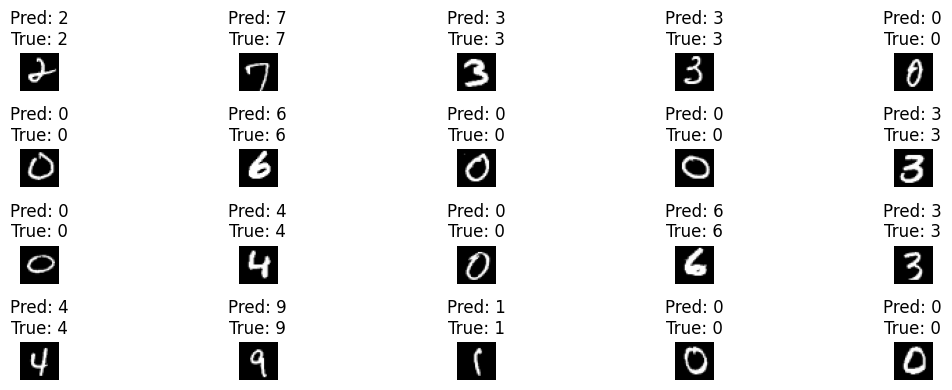

In [ ]:
model.eval()
images, labels = next(iter(val_data))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
  outputs = model(images)
  predictions = outputs.argmax(dim = 1)

# Plotting 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {predictions[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# to print dimensions
images, labels = next(iter(train_data))
patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size = patch_size, stride = patch_size)
embedded_image = patch_embed(images)
print("This is the shape of input image tensor", images.shape)
print("This is the shape of input image tensor after conv2d", patch_embed(images).shape)
print(embedded_image.flatten(2).shape) # we need 3 dim so (2)
print(embedded_image.flatten(2).transpose(1,2).shape)

This is the shape of input image tensor torch.Size([64, 1, 28, 28])
This is the shape of input image tensor after conv2d torch.Size([64, 20, 4, 4])
torch.Size([64, 20, 16])
torch.Size([64, 16, 20])
